# 제주 농산물 가격 예측 고도화 (GeminiGLI2.ipynb)

이 버전은 `데이터 분석.ipynb`의 EMA 로직을 고도화하여 반영하고, Optuna를 이용해 하이퍼파라미터를 최적화한 최종 모델링 파일입니다.

### 주요 개선 사항
1. **품목별 차등 EMA 특성**: 
   - TG: 7, 30, 60, 120일 지수이동평균 추가
   - Others: 7, 30일 지수이동평균 추가
2. **Optuna 하이퍼파라미터 튜닝**: XGB, LGBM, CatBoost 최적화
3. **시각화**: 특성 중요도(Feature Importance) 및 예측 결과 시계열 그래프 출력
4. **앙상블**: 최적화된 모델들의 Voting Ensemble

# 1. 라이브러리 불러오기

In [1]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

try:
    from korean_font import set_korean_font
    set_korean_font()
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)


# 2. 데이터 전처리 및 특성 엔지니어링

In [2]:
def preprocess_with_ema(train_df, test_df, inter_df):
    # 1. 병합 및 기본 처리
    train_df = train_df.rename(columns={'supply(kg)': 'supply', 'price(원/kg)': 'price'})
    
    # 2. 이상치 처리
    outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
    for item, thr in outlier_thresholds.items():
        idx = train_df[(train_df['item'] == item) & (train_df['price'] > thr)].index
        if len(idx) > 0:
            mean_p = train_df[(train_df['item'] == item) & (train_df['price'] != 0)]['price'].mean()
            train_df.loc[idx, 'price'] = mean_p

    # 3. EMA 특성 추가 (중요: Data Leakage 방지를 위해 shift 사용)
    # item, corporation, location 별로 그룹화하여 계산
    print("Calculating EMA features...")
    
    def add_ema(df, windows):
        df = df.sort_values(['item', 'corporation', 'location', 'timestamp'])
        group = df.groupby(['item', 'corporation', 'location'])['price']
        
        for w in windows:
            # 이전 시점의 데이터를 기반으로 EMA 계산 (현재 시점 가격 포함 안함)
            df[f'ema_{w}'] = group.transform(lambda x: x.shift(1).ewm(span=w, min_periods=1).mean())
        return df

    # 모든 품목에 대해 7, 30일 계산 후 TG만 60, 120 추가
    train_df = add_ema(train_df, [7, 30, 60, 120])
    
    # TG가 아닌 품목은 ema_60, ema_120을 0 또는 제거 (요청사항 반영)
    train_df.loc[train_df['item'] != 'TG', ['ema_60', 'ema_120']] = 0

    # 테스트 데이터는 학습 데이터의 마지막 EMA 값을 이어받음 (간단한 구현)
    # 실제 시계열 예측에서는 Recursive하게 업데이트하거나 마지막 추세 반영
    last_ema = train_df.groupby(['item', 'corporation', 'location']).last().reset_index()
    ema_cols = ['ema_7', 'ema_30', 'ema_60', 'ema_120']
    test_df = pd.merge(test_df, last_ema[['item', 'corporation', 'location'] + ema_cols], 
                       on=['item', 'corporation', 'location'], how='left')

    # 4. 타겟 변환
    train_df['target'] = np.where(
        train_df['item'] == 'TG', np.sqrt(train_df['price']), np.log1p(train_df['price'])
    )
    
    # 5. 기본 날짜 특성
    def extract_date_features(df):
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['year'] = df['timestamp'].dt.year
        df['month'] = df['timestamp'].dt.month
        df['day'] = df['timestamp'].dt.day
        df['dow'] = df['timestamp'].dt.dayofweek
        df['week'] = df['timestamp'].dt.isocalendar().week.astype(int)
        
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)
        
        kr_holidays = holidays.KR()
        df['holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
        return df

    train_df = extract_date_features(train_df)
    test_df = extract_date_features(test_df)
    
    # 6. 인코딩
    le_cols = ['item', 'corporation', 'location']
    for col in le_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col])
        test_df[col] = le.transform(test_df[col])
        
    # 7. 무역 데이터 (간소화 결합)
    inter_df['item_name'] = inter_df['품목명'].map({'감귤':'TG', '브로콜리':'BC', '무':'RD', '당근':'CR', '양배추':'CB'})
    inter_df['year_month'] = (pd.to_datetime(inter_df['기간']) + pd.DateOffset(months=1)).dt.to_period('M').astype(str)
    inter_pivot = inter_df.groupby(['year_month', 'item_name'])[['수출 금액', '수입 금액']].sum().reset_index()
    inter_pivot['net_trade'] = inter_pivot['수출 금액'] - inter_pivot['수입 금액']
    
    # item 코드로 다시 매칭
    item_map = {0:'BC', 1:'CB', 2:'CR', 3:'RD', 4:'TG'} # 가나다순 인코딩 기준
    inter_pivot['item'] = inter_pivot['item_name'].map({'BC':0, 'CB':1, 'CR':2, 'RD':3, 'TG':4})
    
    train_df['year_month'] = train_df['timestamp'].dt.to_period('M').astype(str)
    test_df['year_month'] = test_df['timestamp'].dt.to_period('M').astype(str)
    
    train_df = pd.merge(train_df, inter_pivot[['year_month', 'item', 'net_trade']], on=['year_month', 'item'], how='left').fillna(0)
    test_df = pd.merge(test_df, inter_pivot[['year_month', 'item', 'net_trade']], on=['year_month', 'item'], how='left').fillna(0)
    
    return train_df, test_df

DATA_PATH = './data/'
train_raw = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test_raw = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
inter_raw = pd.read_csv(os.path.join(DATA_PATH, 'international_trade.csv'))

train, test = preprocess_with_ema(train_raw, test_raw, inter_raw)

Calculating EMA features...


# 3. 모델링

[I 2026-03-15 19:42:22,379] A new study created in memory with name: no-name-3bf4c21f-55cf-4fb8-8502-25024aad7adc


Optimizing for TG...


[I 2026-03-15 19:42:22,799] Trial 0 finished with value: 6.686257887529431 and parameters: {'n_estimators': 975, 'learning_rate': 0.0377485518633434, 'max_depth': 5, 'num_leaves': 93, 'subsample': 0.6641585117035677, 'colsample_bytree': 0.6019207978729224}. Best is trial 0 with value: 6.686257887529431.
[I 2026-03-15 19:42:25,332] Trial 1 finished with value: 7.276563228381789 and parameters: {'n_estimators': 1537, 'learning_rate': 0.025089298659139853, 'max_depth': 15, 'num_leaves': 134, 'subsample': 0.9160028164673075, 'colsample_bytree': 0.8446066529208422}. Best is trial 0 with value: 6.686257887529431.
[I 2026-03-15 19:42:26,188] Trial 2 finished with value: 7.059763334888605 and parameters: {'n_estimators': 1358, 'learning_rate': 0.04851824838389023, 'max_depth': 7, 'num_leaves': 59, 'subsample': 0.9469598041921912, 'colsample_bytree': 0.7998024329336774}. Best is trial 0 with value: 6.686257887529431.
[I 2026-03-15 19:42:27,341] Trial 3 finished with value: 6.843491940262503 and

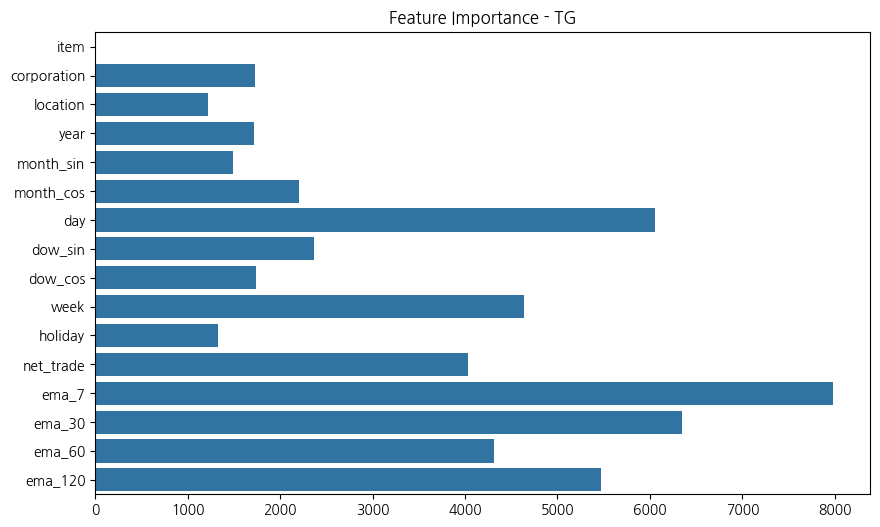

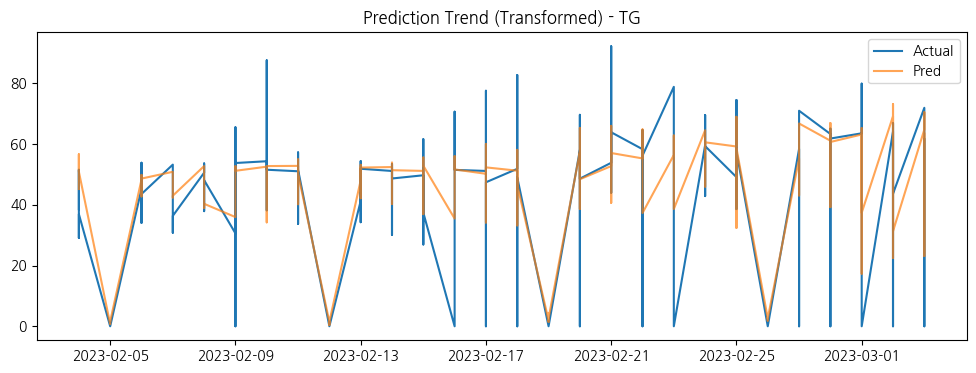

[I 2026-03-15 19:42:56,773] A new study created in memory with name: no-name-9a07f041-ab79-4b63-b819-5cf7ac2b4e13


Optimizing for RD_CR...


[I 2026-03-15 19:42:57,289] Trial 0 finished with value: 1.1519256848266506 and parameters: {'n_estimators': 551, 'learning_rate': 0.01929617857899954, 'max_depth': 7, 'num_leaves': 111, 'subsample': 0.808916769285877, 'colsample_bytree': 0.9384822260769672}. Best is trial 0 with value: 1.1519256848266506.
[I 2026-03-15 19:42:58,687] Trial 1 finished with value: 1.3372325367681837 and parameters: {'n_estimators': 1253, 'learning_rate': 0.04976906143380115, 'max_depth': 9, 'num_leaves': 226, 'subsample': 0.8010107641624477, 'colsample_bytree': 0.6518469640951391}. Best is trial 0 with value: 1.1519256848266506.
[I 2026-03-15 19:42:59,112] Trial 2 finished with value: 1.157165764736404 and parameters: {'n_estimators': 561, 'learning_rate': 0.016730862863436655, 'max_depth': 6, 'num_leaves': 218, 'subsample': 0.6034073352919636, 'colsample_bytree': 0.8498698178912973}. Best is trial 0 with value: 1.1519256848266506.
[I 2026-03-15 19:42:59,625] Trial 3 finished with value: 1.22795858533098

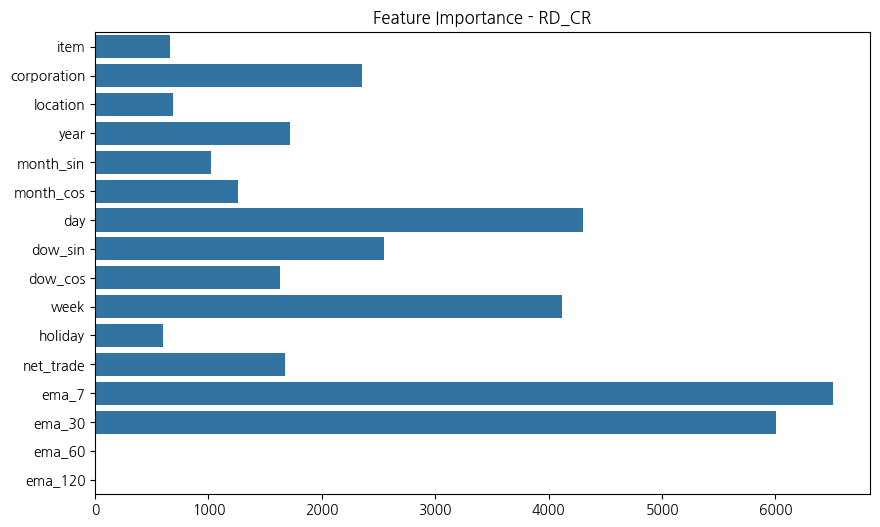

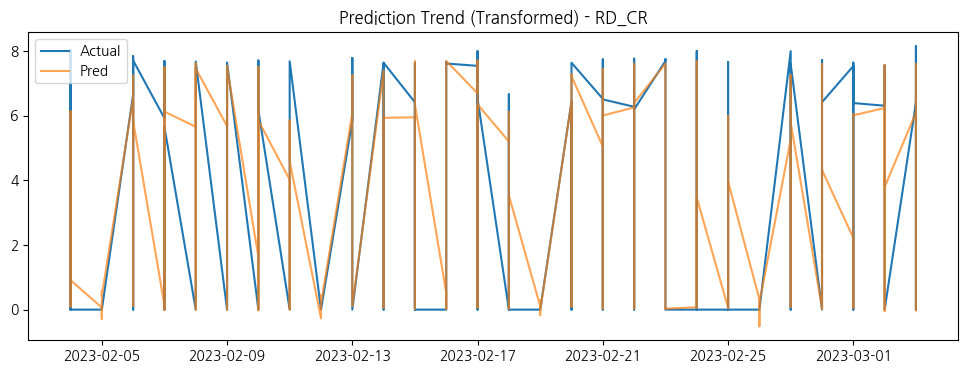

[I 2026-03-15 19:43:29,599] A new study created in memory with name: no-name-e9c92bf7-6211-48c8-a517-9e33fc68fb15


Optimizing for BC_CB...


[I 2026-03-15 19:43:31,836] Trial 0 finished with value: 0.8579269771402078 and parameters: {'n_estimators': 1346, 'learning_rate': 0.015036694326188746, 'max_depth': 13, 'num_leaves': 130, 'subsample': 0.766677530383639, 'colsample_bytree': 0.833584898663685}. Best is trial 0 with value: 0.8579269771402078.
[I 2026-03-15 19:43:34,692] Trial 1 finished with value: 0.8542282589489885 and parameters: {'n_estimators': 1101, 'learning_rate': 0.00725005223689788, 'max_depth': 14, 'num_leaves': 237, 'subsample': 0.8478009103107613, 'colsample_bytree': 0.8704654202732245}. Best is trial 1 with value: 0.8542282589489885.
[I 2026-03-15 19:43:35,255] Trial 2 finished with value: 0.8385695435611159 and parameters: {'n_estimators': 757, 'learning_rate': 0.015337034105744163, 'max_depth': 6, 'num_leaves': 221, 'subsample': 0.9094749789337164, 'colsample_bytree': 0.7056552401378172}. Best is trial 2 with value: 0.8385695435611159.
[I 2026-03-15 19:43:37,135] Trial 3 finished with value: 0.9843449778

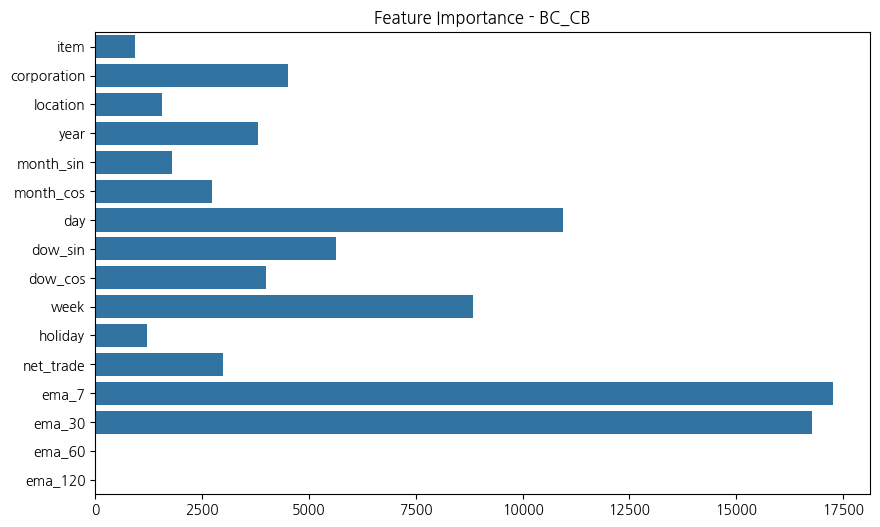

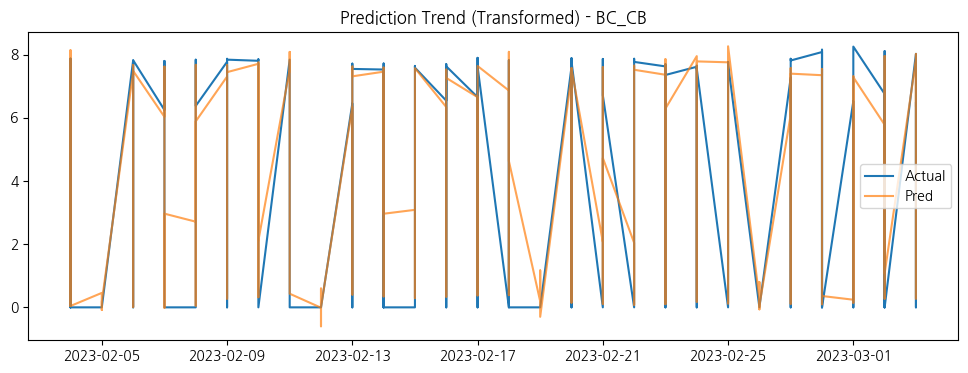

In [3]:
def optimize_models(X_train, y_train, X_val, y_val, item_type):
    def objective_lgbm(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'num_leaves': trial.suggest_int('num_leaves', 31, 255),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42, 'verbose': -1
        }
        model = LGBMRegressor(**params)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        return mean_absolute_error(y_val, pred)

    print(f"Optimizing for {item_type}...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective_lgbm, n_trials=20)
    return study.best_params

# 품목 그룹화 학습
features = ['item', 'corporation', 'location', 'year', 'month_sin', 'month_cos', 'day', 'dow_sin', 'dow_cos', 'week', 'holiday', 'net_trade', 'ema_7', 'ema_30', 'ema_60', 'ema_120']

def train_optimized_group(df, group_name):
    df = df.sort_values('timestamp')
    split_date = df['timestamp'].max() - pd.Timedelta(days=28)
    
    train_data = df[df['timestamp'] <= split_date]
    val_data = df[df['timestamp'] > split_date]
    
    X_train, y_train = train_data[features], train_data['target']
    X_val, y_val = val_data[features], val_data['target']
    
    best_params = optimize_models(X_train, y_train, X_val, y_val, group_name)
    
    lgbm = LGBMRegressor(**best_params)
    xgb = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=7, random_state=42)
    cat = CatBoostRegressor(iterations=1000, learning_rate=0.01, depth=7, random_state=42, verbose=0)
    
    model = VotingRegressor([('lgbm', lgbm), ('xgb', xgb), ('cat', cat)])
    model.fit(X_train, y_train)
    
    # 시각화 1: 특성 중요도 (LGBM 기준)
    lgbm.fit(X_train, y_train)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=lgbm.feature_importances_, y=features)
    plt.title(f'Feature Importance - {group_name}')
    plt.show()
    
    # 시각화 2: 예측 그래프
    v_pred = model.predict(X_val)
    plt.figure(figsize=(12, 4))
    plt.plot(val_data['timestamp'], val_data['target'].values, label='Actual')
    plt.plot(val_data['timestamp'], v_pred, label='Pred', alpha=0.7)
    plt.title(f'Prediction Trend (Transformed) - {group_name}')
    plt.legend()
    plt.show()
    
    return model

train_g1 = train[train['item'] == 4]
train_g2 = train[train['item'].isin([2, 3])]
train_g3 = train[train['item'].isin([0, 1])]

model1 = train_optimized_group(train_g1, "TG")
model2 = train_optimized_group(train_g2, "RD_CR")
model3 = train_optimized_group(train_g3, "BC_CB")

# 4. 예측 결과 저장

In [ ]:
def predict_and_postprocess(test_data, model):
    pred = model.predict(test_data[features])
    
    test_data['answer'] = np.where(
        test_data['item'] == 4, 
        np.power(np.maximum(0, pred), 2),
        np.expm1(np.maximum(0, pred))
    )
    
    # 일요일 0원 처리
    test_data.loc[test_data['dow'] == 6, 'answer'] = 0
    # 음수 방지
    test_data.loc[test_data['answer'] < 0, 'answer'] = 0
    
    return test_data[['ID', 'answer']]

sub1 = predict_and_postprocess(test[test['item'] == 4], model1)
sub2 = predict_and_postprocess(test[test['item'].isin([2, 3])], model2)
sub3 = predict_and_postprocess(test[test['item'].isin([0, 1])], model3)

final_sub = pd.concat([sub1, sub2, sub3])
sample_sub = pd.read_csv('./data/sample_submission.csv')
submission = pd.merge(sample_sub[['ID']], final_sub, on='ID', how='left')
submission.to_csv('submission.csv', index=False)
print("최종 결과 파일 submission.csv 생성 완료")

최종 결과 파일 submission16.csv 생성 완료
